importing the dependencies

In [ ]:
import numpy as np #making numpy arrays
import pandas as pd #making data frames, used to analyse and process the data
import matplotlib.pyplot as plt #plots and graphs
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

#train_test_split → splits data
#GridSearchCV → finds best parameters
#cross_val_score → validates model reliability
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

#What:
#Scales features (normalization)
#Why:
#Different features (age, bmi) have different scales → can confuse models
from sklearn.preprocessing import StandardScaler

#What:
#Different evaluation metrics
#Why:
#R² alone is misleading
#RMSE shows real error magnitude
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#What
#Advanced ML model
#Why
#Replaces weak Linear Regression → captures complex patterns
from sklearn.ensemble import RandomForestRegressor

#What
#Saves trained model
#Why
#Makes project deployable (very important for resume)
import joblib


data collection and analysis

In [ ]:
#loading the data from csv to panda dataframe
insurance_dataset = pd.read_csv('/content/insurance.csv')

In [ ]:
#first 5 rows of dataframe
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# number of rows and columns
insurance_dataset.shape

(1338, 7)

In [ ]:
# getting some information about the dataset
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


categorical feature :
-sex
-smoker
-region

In [ ]:
#checking for missing values
insurance_dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


data analysis

In [ ]:
#stastical measures of dataset
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


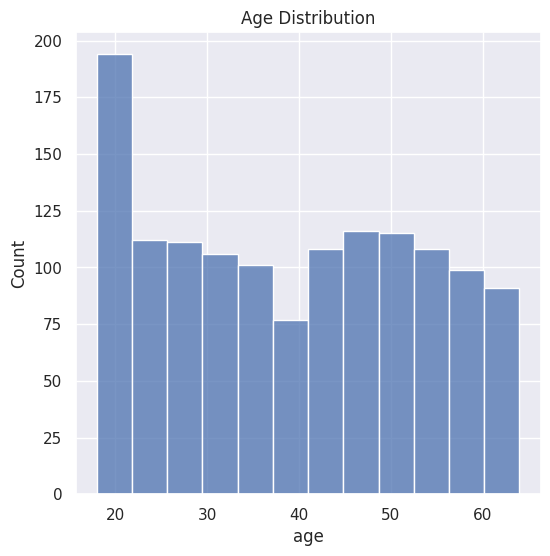

In [ ]:
#distribution of age value
sns.set()
plt.figure(figsize=(6, 6)) #size of the plot
sns.histplot(insurance_dataset['age']) #how the values are distributed inside the dataset
plt.title('Age Distribution')
plt.show()

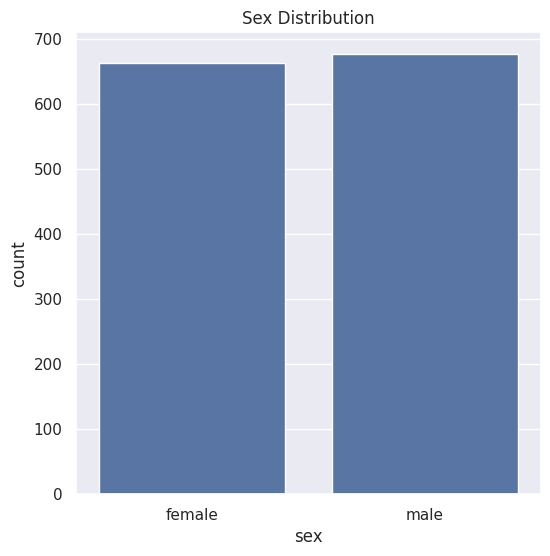

In [ ]:
# Gender column(categorical data)

plt.figure(figsize=(6, 6))
sns.countplot(x = 'sex', data = insurance_dataset)
plt.title('Sex Distribution')
plt.show()

In [ ]:
insurance_dataset['sex'].value_counts()

,count
sex,
male,676
female,662


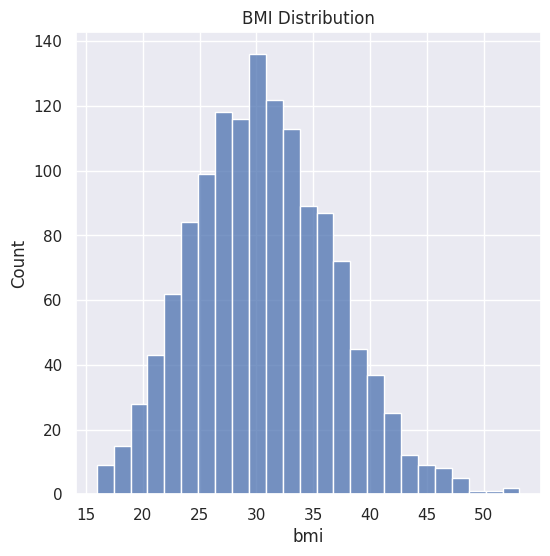

In [ ]:
# bmi distribution
plt.figure(figsize=(6, 6)) #size of the plot
sns.histplot(insurance_dataset['bmi']) #how the values are distributed inside the dataset
plt.title('BMI Distribution')
plt.show()

normal bmi range --> 18.5 to 24.9
calculated using height and wt
lots of people in this dataset are overwt

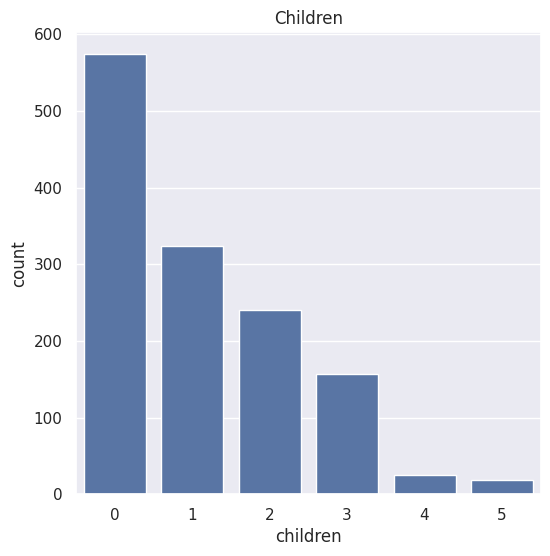

In [ ]:
# children column
plt.figure(figsize=(6, 6))
sns.countplot(x = 'children', data = insurance_dataset)
plt.title('Children')
plt.show()

In [ ]:
insurance_dataset['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


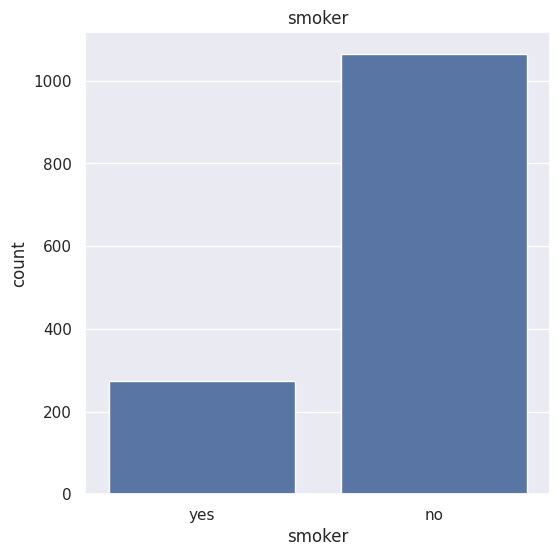

In [ ]:
plt.figure(figsize=(6, 6))
sns.countplot(x = 'smoker', data = insurance_dataset)
plt.title('smoker')
plt.show()

In [ ]:
insurance_dataset['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


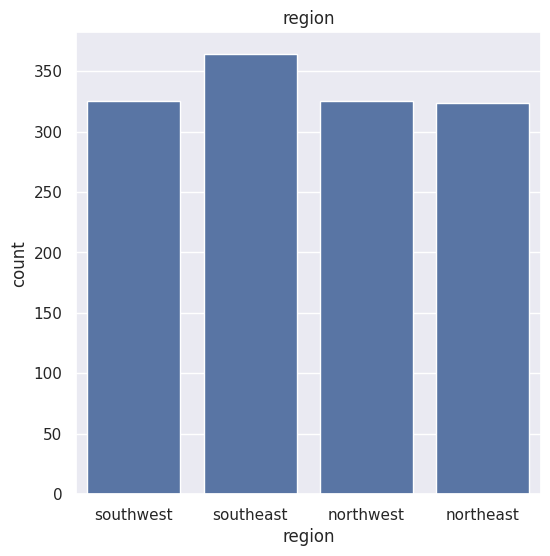

In [ ]:
# region column
plt.figure(figsize=(6, 6))
sns.countplot(x = 'region', data = insurance_dataset)
plt.title('region')
plt.show()

In [ ]:
insurance_dataset['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


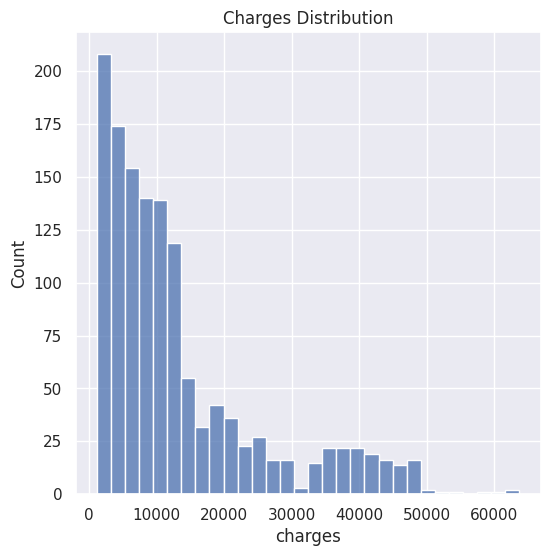

In [ ]:
plt.figure(figsize=(6, 6)) #size of the plot
sns.histplot(insurance_dataset['charges']) #how the values are distributed inside the dataset
plt.title('Charges Distribution')
plt.show()

Data preprocessing
- it dosnt understand text well so we use numerical value
- give a numerical value

Encoding the categorical features

In [ ]:
insurance_dataset = pd.get_dummies(
    insurance_dataset,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)
#In real datasets:

#region is nominal
#Label encoding introduces false patterns

#👉 Research + projects confirm:

#One-hot encoding is standard preprocessing step



Splitting the features and target


In [ ]:
# axis = 1 --> column & axis = 0 --> row
X = insurance_dataset.drop(columns= 'charges', axis = 1)
Y = insurance_dataset['charges']

In [ ]:
print(X) #contains all the columns except charges

      age     bmi  children  sex_male  smoker_yes  region_northwest  \
0      19  27.900         0     False        True             False   
1      18  33.770         1      True       False             False   
2      28  33.000         3      True       False             False   
3      33  22.705         0      True       False              True   
4      32  28.880         0      True       False              True   
...   ...     ...       ...       ...         ...               ...   
1333   50  30.970         3      True       False              True   
1334   18  31.920         0     False       False             False   
1335   18  36.850         0     False       False             False   
1336   21  25.800         0     False       False             False   
1337   61  29.070         0     False        True              True   

      region_southeast  region_southwest  
0                False              True  
1                 True             False  
2                 

In [ ]:
print(Y) # contains the charges column
# it basically split the charges and features

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


🤔 Why are we doing this?

Your model (Linear Regression) thinks like this:

👉 “If BMI increases, cost increases in a straight line”

But real life is more like:

👉 “After a certain BMI, cost increases very fast”

So we give model extra help by adding:

BMI
BMI²

In [ ]:
insurance_dataset['bmi_squared'] = insurance_dataset['bmi'] ** 2

🤔 Why are we doing this?

Your model currently sees:

age separately
bmi separately

But in real life:

👉 “High BMI is more dangerous for older people”

So instead of:

age effect
bmi effect

We add:
👉 combined effect (age × bmi)

In [ ]:
insurance_dataset['age_bmi'] = insurance_dataset['age'] * insurance_dataset['bmi']

🤔 Why this is powerful

In real life:

👉 Smoking + High BMI = VERY expensive insurance

This combination is much more dangerous than:

just smoking
just high BMI

So we are telling model:

👉 “Look carefully when BOTH happen together”

In [ ]:
insurance_dataset['smoker_bmi'] = insurance_dataset['bmi'] * insurance_dataset['smoker_yes']

Splitting the data into training and testing data

In [ ]:
# corresponding x test charges values goes to y test and same for x train
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)
# Total data = 1338 rows
# Training = 1070 rows (80%)
# Testing = 268 rows (20%)

(1338, 8) (1070, 8) (268, 8)


model training

Random Forest model


In [ ]:
# 1. Create model
model = RandomForestRegressor()

# 2. Train
model.fit(X_train, Y_train)

# 3. Predict
y_pred = model.predict(X_test)

# 4. Evaluate

model evaluation

In [ ]:
# prediction on trianing data
training_data_prediction = model.predict(X_train)

In [ ]:
# R squared value if our value is close to 1 then our  model is performing well
r2_train = metrics.r2_score(Y_train, training_data_prediction)
print('R squared value: ', r2_train)

R squared value:  0.9774173636099448


why to predict on training and testing data overtraning in ml model will overlearn on trianing data which isnt necessary --> we will get huge value for training data and very less for testing data

In [ ]:
# prediction on test data
test_data_prediction = model.predict(X_test)

In [ ]:
# R squared value
r2_test = metrics.r2_score(Y_test, test_data_prediction)
print('R squared value : ', r2_test)

R squared value :  0.8388595785400981


building a predictive system

In [ ]:
# Correct order example:
# age, sex, bmi, children, smoker, region_northwest, region_southeast, region_southwest

input_data = [31, 1, 25.74, 0, 1, 0, 0, 1]

input_df = pd.DataFrame([input_data], columns=X.columns)

prediction = model.predict(input_df)

print("Insurance cost is USD:", prediction[0])

Insurance cost is USD: 23287.747436399983


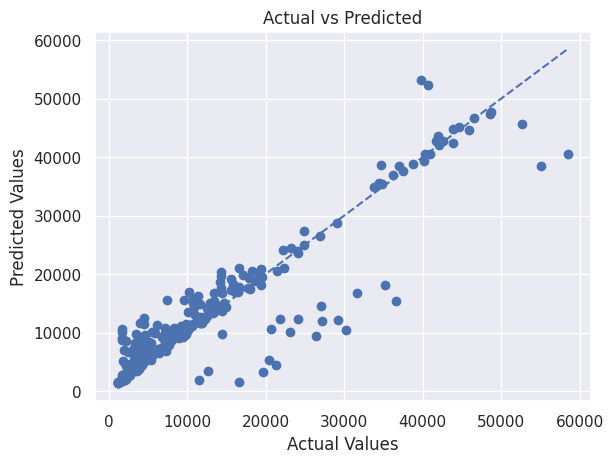

In [ ]:
import matplotlib.pyplot as plt

Y_pred = model.predict(X_test)

plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

# Perfect prediction line
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         linestyle='--')

plt.show()